In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load feature store and segments
features  = pd.read_csv("..\\data\\processed\\customer_features.csv")
segments  = pd.read_csv("..\\data\\processed\\customer_segments.csv")[
    ['customer_id', 'cluster', 'segment', 'spend_tier']
]
df = features.merge(segments, on='customer_id', how='left')
df['segment_code'] = pd.Categorical(df['spend_tier']).codes

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")


Dataset shape: (96478, 30)
Columns: ['customer_id', 'recency_days', 'frequency', 'monetary', 'avg_order_value', 'first_order_date', 'last_order_date', 'tenure_days', 'category_diversity', 'favourite_category', 'avg_review_score', 'review_count', 'is_reviewer', 'avg_delivery_days', 'avg_delivery_delta', 'late_deliveries', 'preferred_payment', 'avg_installments', 'max_installments', 'high_installment_flag', 'weekend_purchase_rate', 'freight_to_revenue_ratio', 'log_frequency', 'log_monetary', 'log_avg_order_value', 'log_recency', 'cluster', 'segment', 'spend_tier', 'segment_code']


In [2]:
import duckdb

con = duckdb.connect("..\\data\ecommerce.db")

# Pull order history per unique customer
# Note: customer_id in Olist is per-order, customer_unique_id is the true repeat identifier
order_history = con.execute("""
    SELECT
        c.customer_unique_id,
        o.customer_id,
        o.purchased_at::DATE        AS order_date,
        o.order_status,
        SUM(oi.price)               AS order_value
    FROM orders_clean o
    JOIN customers c         USING (customer_id)
    JOIN order_items_clean oi USING (order_id)
    WHERE o.order_status = 'delivered'
    GROUP BY
        c.customer_unique_id,
        o.customer_id,
        o.purchased_at::DATE,
        o.order_status
""").df()

con.close()

print(f"Order history shape: {order_history.shape}")
print(order_history.head(3))


Order history shape: (96478, 5)
                 customer_unique_id                       customer_id  \
0  dd992305cba295d997f263dbdf4e8c2e  b6368ca0f56d4632f44d58ca431487b2   
1  b3548d0cec408ae13d143bb4eeebaa6c  a02f66c3af7b16eec19ddcd98b645fe3   
2  0b48151c4ac827afeee06ce2d77cc343  8df178ced93d8d488dfceefc8f619d9a   

  order_date order_status  order_value  
0 2018-02-11    delivered        34.99  
1 2017-10-01    delivered        19.90  
2 2018-01-13    delivered        89.00  


In [3]:
con = duckdb.connect("..\\data\ecommerce.db")

# Features that could differ between one-time and repeat buyers
churn_specific = con.execute(f"""
    WITH customer_first_order AS (
        -- Get only the first order per unique customer
        SELECT
            c.customer_unique_id,
            o.customer_id,
            o.order_id,
            o.purchased_at::DATE        AS order_date,
            o.actual_delivery_days,
            o.delivery_delta_days,
            EXTRACT(month FROM o.purchased_at) AS order_month,
            EXTRACT(dow   FROM o.purchased_at) AS order_dow,
            EXTRACT(hour  FROM o.purchased_at) AS order_hour
        FROM orders_clean o
        JOIN customers c USING (customer_id)
        WHERE o.order_status = 'delivered'
        QUALIFY ROW_NUMBER() OVER (
            PARTITION BY c.customer_unique_id
            ORDER BY o.purchased_at
        ) = 1
    ),
    order_value_features AS (
        SELECT
            o.order_id,
            COUNT(oi.order_item_id)             AS n_items,
            SUM(oi.price)                       AS order_value,
            SUM(oi.freight_value)               AS freight_value,
            SUM(oi.freight_value) /
                NULLIF(SUM(oi.price + oi.freight_value), 0) AS freight_pct,
            COUNT(DISTINCT oi.product_id)       AS distinct_products,
            AVG(p.weight_g)                     AS avg_product_weight,
            COUNT(DISTINCT p.category_en)       AS categories_in_order
        FROM order_items_clean oi
        JOIN products_clean p USING (product_id)
        JOIN orders_clean o   USING (order_id)
        GROUP BY o.order_id
    ),
    payment_features AS (
        SELECT
            order_id,
            payment_type,
            payment_installments,
            payment_value
        FROM payments
        QUALIFY ROW_NUMBER() OVER (
            PARTITION BY order_id ORDER BY payment_sequential
        ) = 1
    ),
    review_features AS (
        SELECT
            order_id,
            review_score,
            CASE WHEN review_comment_message IS NOT NULL
                 THEN 1 ELSE 0 END AS left_comment
        FROM reviews
    )
    SELECT
        cfo.customer_unique_id,
        cfo.customer_id,

        -- Order timing signals
        cfo.order_month,
        cfo.order_dow,
        cfo.order_hour,
        CASE WHEN cfo.order_dow IN (0,6) THEN 1 ELSE 0 END AS first_order_weekend,

        -- Delivery experience on first order
        COALESCE(cfo.actual_delivery_days, 0)  AS first_delivery_days,
        COALESCE(cfo.delivery_delta_days, 0)   AS first_delivery_delta,
        CASE WHEN cfo.delivery_delta_days < 0
             THEN 1 ELSE 0 END                 AS first_order_late,

        -- Order composition
        COALESCE(ovf.n_items, 1)               AS first_order_items,
        COALESCE(ovf.order_value, 0)           AS first_order_value,
        COALESCE(ovf.freight_pct, 0)           AS first_order_freight_pct,
        COALESCE(ovf.distinct_products, 1)     AS first_order_products,
        COALESCE(ovf.categories_in_order, 1)   AS first_order_categories,
        COALESCE(ovf.avg_product_weight, 0)    AS first_order_avg_weight,

        -- Payment on first order
        COALESCE(pf.payment_installments, 1)   AS first_order_installments,
        COALESCE(pf.payment_type, 'unknown')   AS first_order_payment_type,

        -- Review of first order
        COALESCE(rf.review_score, 3)           AS first_order_review,
        COALESCE(rf.left_comment, 0)           AS first_order_left_comment

    FROM customer_first_order cfo
    LEFT JOIN order_value_features ovf ON cfo.order_id = ovf.order_id
    LEFT JOIN payment_features pf      ON cfo.order_id = pf.order_id
    LEFT JOIN review_features rf       ON cfo.order_id = rf.order_id
""").df()

con.close()

print(f"Churn-specific features: {churn_specific.shape}")
print(churn_specific.head(3).T)

Churn-specific features: (93656, 19)
                                                         0  \
customer_unique_id        f94d7c267f1bb6956a0c6c6fef65da8b   
customer_id               4b4773853bbbc435ddddd51bd6c6a002   
order_month                                              8   
order_dow                                                3   
order_hour                                              14   
first_order_weekend                                      0   
first_delivery_days                                     13   
first_delivery_delta                                    14   
first_order_late                                         0   
first_order_items                                        1   
first_order_value                                    29.99   
first_order_freight_pct                           0.337969   
first_order_products                                     1   
first_order_categories                                   1   
first_order_avg_weight           

In [4]:
SNAPSHOT_DATE = pd.Timestamp("2018-10-18")
CHURN_DAYS    = 90

# Aggregate to one row per unique customer
customer_orders = order_history.groupby('customer_unique_id').agg(
    first_order_date = ('order_date', 'min'),
    last_order_date  = ('order_date', 'max'),
    total_orders     = ('order_date', 'count'),
    total_revenue    = ('order_value', 'sum'),
).reset_index()

# Only keep customers whose first order was 90+ days before snapshot
# — gives them adequate time to have made a repeat purchase
customer_orders['days_since_first'] = (
    SNAPSHOT_DATE - pd.to_datetime(customer_orders['first_order_date'])
).dt.days

eligible = customer_orders[
    customer_orders['days_since_first'] >= CHURN_DAYS
].copy()

# Target: returned = 1 (made repeat purchase), 0 = one-time buyer (churned)
# Predicting RETURN makes the minority class the positive label
# which is correct for imbalanced learning with scale_pos_weight
eligible['returned'] = (eligible['total_orders'] > 1).astype(int)
eligible['churned']  = (eligible['total_orders'] == 1).astype(int)

print(f"Eligible customers (first order 90+ days ago): {len(eligible):,}")
print(f"\nLabel distribution:")
ret = eligible['returned'].value_counts()
print(f"  One-time buyer (returned=0): {ret.get(0,0):>8,} "
      f"({ret.get(0,0)/len(eligible):.1%})")
print(f"  Repeat buyer   (returned=1): {ret.get(1,0):>8,} "
      f"({ret.get(1,0)/len(eligible):.1%})")

Eligible customers (first order 90+ days ago): 84,701

Label distribution:
  One-time buyer (returned=0):   81,967 (96.8%)
  Repeat buyer   (returned=1):    2,734 (3.2%)


In [5]:
# Bridge: customer_unique_id → most recent customer_id
order_history_eligible = order_history[
    order_history['customer_unique_id'].isin(eligible['customer_unique_id'])
]

id_bridge = (
    order_history_eligible
    .sort_values('order_date')
    .groupby('customer_unique_id')
    .last()
    .reset_index()[['customer_unique_id', 'customer_id']]
)

churn_labels = eligible.merge(id_bridge, on='customer_unique_id', how='left')

print(f"churn_labels shape: {churn_labels.shape}")
print(f"Columns: {churn_labels.columns.tolist()}")
print(churn_labels[['customer_id','returned','churned','total_orders']].head(5))

churn_labels shape: (84701, 9)
Columns: ['customer_unique_id', 'first_order_date', 'last_order_date', 'total_orders', 'total_revenue', 'days_since_first', 'returned', 'churned', 'customer_id']
                        customer_id  returned  churned  total_orders
0  fadbb3709178fc513abc1b2670aa1ad2         0        1             1
1  4cb282e167ae9234755102258dd52ee8         0        1             1
2  9b3932a6253894a02c1df9d19004239f         0        1             1
3  914991f0c02ef0843c0e7010c819d642         0        1             1
4  47227568b10f5f58a524a75507e6992c         0        1             1


In [6]:
# Reload clean base
features = pd.read_csv("../data/processed/customer_features.csv")
segments = pd.read_csv("../data/processed/customer_segments.csv")[
    ['customer_id', 'cluster', 'segment', 'spend_tier']
]

df = features.merge(segments, on='customer_id', how='left')
df['segment_code'] = pd.Categorical(df['spend_tier']).codes

# Drop conflict columns from previous reruns
conflict_cols = ['first_order_date', 'last_order_date', 'total_orders',
                 'total_revenue', 'days_since_first', 'returned',
                 'churned', 'customer_unique_id']
df = df.drop(columns=[c for c in conflict_cols if c in df.columns])

# Merge churn labels
required_in_churn = ['customer_id', 'returned', 'churned',
                     'total_orders', 'first_order_date', 'days_since_first']
df = df.merge(churn_labels[required_in_churn], on='customer_id', how='inner')

# Merge new churn-specific first-order features
churn_specific_cols = [c for c in churn_specific.columns
                       if c not in ['customer_unique_id']]
df = df.merge(
    churn_specific[churn_specific_cols],
    on='customer_id',
    how='left'
)

# Encode first_order_payment_type
df['first_order_payment_code'] = pd.Categorical(
    df['first_order_payment_type']
).codes

print(f"Final dataset shape: {df.shape}")
print(f"Return rate:  {df['returned'].mean():.1%}")
print(f"Churn rate:   {df['churned'].mean():.1%}")
print(f"Any nulls:    {df.isnull().sum().sum()}")

Final dataset shape: (84893, 51)
Return rate:  3.3%
Churn rate:   96.7%
Any nulls:    40069


In [7]:
print("churn_labels columns:", churn_labels.columns.tolist())
print("churn_labels shape:", churn_labels.shape)
print(churn_labels.head(3))

churn_labels columns: ['customer_unique_id', 'first_order_date', 'last_order_date', 'total_orders', 'total_revenue', 'days_since_first', 'returned', 'churned', 'customer_id']
churn_labels shape: (84701, 9)
                 customer_unique_id first_order_date last_order_date  \
0  0000366f3b9a7992bf8c76cfdf3221e2       2018-05-10      2018-05-10   
1  0000b849f77a49e4a4ce2b2a4ca5be3f       2018-05-07      2018-05-07   
2  0000f46a3911fa3c0805444483337064       2017-03-10      2017-03-10   

   total_orders  total_revenue  days_since_first  returned  churned  \
0             1          129.9               161         0        1   
1             1           18.9               164         0        1   
2             1           69.0               587         0        1   

                        customer_id  
0  fadbb3709178fc513abc1b2670aa1ad2  
1  4cb282e167ae9234755102258dd52ee8  
2  9b3932a6253894a02c1df9d19004239f  


In [8]:
CHURN_FEATURES = [
    'log_recency',
    'log_frequency',
    'log_monetary',
    'log_avg_order_value',
    'category_diversity',
    'avg_review_score',
    'review_count',
    'is_reviewer',
    'avg_delivery_days',
    'avg_delivery_delta',
    'late_deliveries',
    'avg_installments',
    'max_installments',
    'high_installment_flag',
    'weekend_purchase_rate',
    'freight_to_revenue_ratio',
    'tenure_days',
    'segment_code',
]

X = df[CHURN_FEATURES].copy()
y = df['returned'].copy()   # 1 = came back, 0 = churned

print(f"Feature matrix: {X.shape}")
print(f"Target distribution:\n{y.value_counts().to_string()}")
print(f"Any nulls in X: {X.isnull().sum().sum()}")

# Sanity check
assert X.isnull().sum().sum() == 0, "Nulls detected — fix before continuing"
assert y.nunique() == 2,            "Target must be binary"

Feature matrix: (84893, 18)
Target distribution:
returned
0    82057
1     2836
Any nulls in X: 0


In [9]:
print("churn_labels columns:", churn_labels.columns.tolist())
print("churn_labels shape:",   churn_labels.shape)
print(churn_labels[['customer_id', 'first_order_date']].head(3))

churn_labels columns: ['customer_unique_id', 'first_order_date', 'last_order_date', 'total_orders', 'total_revenue', 'days_since_first', 'returned', 'churned', 'customer_id']
churn_labels shape: (84701, 9)
                        customer_id first_order_date
0  fadbb3709178fc513abc1b2670aa1ad2       2018-05-10
1  4cb282e167ae9234755102258dd52ee8       2018-05-07
2  9b3932a6253894a02c1df9d19004239f       2017-03-10


In [10]:
neg = (y == 0).sum()   # one-time buyers (majority)
pos = (y == 1).sum()   # returned customers (minority = positive class)

SCALE_POS_WEIGHT = round(neg / pos, 2)

print(f"One-time buyers (0): {neg:,}  ({neg/len(y):.1%})")
print(f"Returned        (1): {pos:,}  ({pos/len(y):.1%})")
print(f"Imbalance ratio:     {SCALE_POS_WEIGHT:.1f}:1")
print(f"scale_pos_weight:    {SCALE_POS_WEIGHT}")

One-time buyers (0): 82,057  (96.7%)
Returned        (1): 2,836  (3.3%)
Imbalance ratio:     28.9:1
scale_pos_weight:    28.93


In [11]:
# Cell 9 — time-based split
if 'first_order_date' not in df.columns:
    raise RuntimeError(
        "first_order_date not in df.\n"
        "Fix: rerun cells 4 → 5 → 6 in order, then rerun this cell."
    )

df['first_order_date'] = pd.to_datetime(df['first_order_date'])

# Drop any rows where first_order_date is null
before = len(df)
df = df.dropna(subset=['first_order_date']).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with null first_order_date")

# Sort chronologically — no data leakage
df_sorted = df.sort_values('first_order_date').reset_index(drop=True)

n         = len(df_sorted)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_sorted.iloc[:train_end]
val_df   = df_sorted.iloc[train_end:val_end]
test_df  = df_sorted.iloc[val_end:]

X_train = train_df[CHURN_FEATURES]
y_train = train_df['returned']
X_val   = val_df[CHURN_FEATURES]
y_val   = val_df['returned']
X_test  = test_df[CHURN_FEATURES]
y_test  = test_df['returned']

print(f"Train: {X_train.shape} | return rate: {y_train.mean():.1%}")
print(f"Val:   {X_val.shape}   | return rate: {y_val.mean():.1%}")
print(f"Test:  {X_test.shape}  | return rate: {y_test.mean():.1%}")

Dropped 0 rows with null first_order_date
Train: (59425, 18) | return rate: 4.0%
Val:   (12734, 18)   | return rate: 2.0%
Test:  (12734, 18)  | return rate: 1.5%


In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {pd.Series(y_train).value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_smote).value_counts().to_dict()}")

Before SMOTE: {0: 57032, 1: 2393}
After SMOTE:  {0: 57032, 1: 57032}


In [13]:
import xgboost as xgb

dtrain       = xgb.DMatrix(X_train,       label=y_train,       feature_names=CHURN_FEATURES)
dtrain_smote = xgb.DMatrix(X_train_smote, label=y_train_smote, feature_names=CHURN_FEATURES)
dval         = xgb.DMatrix(X_val,         label=y_val,         feature_names=CHURN_FEATURES)
dtest        = xgb.DMatrix(X_test,        label=y_test,        feature_names=CHURN_FEATURES)

print("DMatrix objects created.")
print(f"dtrain rows:       {dtrain.num_row():,}")
print(f"dtrain_smote rows: {dtrain_smote.num_row():,}")
print(f"dval rows:         {dval.num_row():,}")
print(f"dtest rows:        {dtest.num_row():,}")

DMatrix objects created.
dtrain rows:       59,425
dtrain_smote rows: 114,064
dval rows:         12,734
dtest rows:        12,734


In [14]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

def evaluate_model(model, dmatrix, y_true, label="", threshold=0.5):
    y_prob = model.predict(dmatrix)
    y_pred = (y_prob >= threshold).astype(int)

    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc  = average_precision_score(y_true, y_prob)

    print(f"\n{'='*45}")
    print(f"Evaluation: {label}")
    print(f"{'='*45}")
    print(f"  ROC-AUC:  {roc_auc:.4f}")
    print(f"  PR-AUC:   {pr_auc:.4f}  <- primary metric")
    print(f"\nClassification Report (threshold={threshold}):")
    print(classification_report(
        y_true, y_pred,
        target_names=['One-time (churned)', 'Returned']
    ))
    cm = confusion_matrix(y_true, y_pred)
    print(f"Confusion Matrix:")
    print(f"  TN={cm[0,0]:,}  FP={cm[0,1]:,}")
    print(f"  FN={cm[1,0]:,}  TP={cm[1,1]:,}")
    return roc_auc, pr_auc, y_prob

In [15]:
params_baseline = {
    'objective':        'binary:logistic',
    'eval_metric':      ['logloss', 'aucpr'],
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'max_depth':        4,
    'learning_rate':    0.05,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 10,
    'seed':             42,
}

evals_result_baseline = {}

print("Training baseline XGBoost (scale_pos_weight)...")
baseline_model = xgb.train(
    params_baseline,
    dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=100,
    evals_result=evals_result_baseline,
    verbose_eval=100,
)

print(f"\nBest iteration: {baseline_model.best_iteration}")
roc_b, pr_b, _ = evaluate_model(
    baseline_model, dval, y_val, "Baseline (scale_pos_weight) — Validation"
)

Training baseline XGBoost (scale_pos_weight)...
[0]	train-logloss:0.77672	train-aucpr:0.33164	val-logloss:0.83783	val-aucpr:0.03323
[100]	train-logloss:0.55376	train-aucpr:0.45972	val-logloss:5.38541	val-aucpr:0.02949
[101]	train-logloss:0.55283	train-aucpr:0.46008	val-logloss:5.38455	val-aucpr:0.03149

Best iteration: 1

Evaluation: Baseline (scale_pos_weight) — Validation
  ROC-AUC:  0.6315
  PR-AUC:   0.0321  <- primary metric

Classification Report (threshold=0.5):
                    precision    recall  f1-score   support

One-time (churned)       1.00      0.00      0.00     12476
          Returned       0.02      1.00      0.04       258

          accuracy                           0.02     12734
         macro avg       0.51      0.50      0.02     12734
      weighted avg       0.98      0.02      0.00     12734

Confusion Matrix:
  TN=5  FP=12,471
  FN=0  TP=258


In [16]:
params_smote = {
    'objective':        'binary:logistic',
    'eval_metric':      ['logloss', 'aucpr'],
    'max_depth':        4,
    'learning_rate':    0.05,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 10,
    'seed':             42,
    # No scale_pos_weight — SMOTE already balanced the classes
}

evals_result_smote = {}

print("Training XGBoost on SMOTE-resampled data...")
smote_model = xgb.train(
    params_smote,
    dtrain_smote,
    num_boost_round=1000,
    evals=[(dtrain_smote, 'train'), (dval, 'val')],
    early_stopping_rounds=30,
    evals_result=evals_result_smote,
    verbose_eval=100,
)

print(f"\nBest iteration: {smote_model.best_iteration}")
roc_s, pr_s, _ = evaluate_model(
    smote_model, dval, y_val, "SMOTE model — Validation"
)

# Pick the better model for tuning
print(f"\nBaseline ROC-AUC: {roc_b:.4f} | PR-AUC: {pr_b:.4f}")
print(f"SMOTE    ROC-AUC: {roc_s:.4f} | PR-AUC: {pr_s:.4f}")
best_base_model = baseline_model if roc_b >= roc_s else smote_model
best_dtrain     = dtrain         if roc_b >= roc_s else dtrain_smote
print(f"\nUsing {'baseline' if roc_b >= roc_s else 'SMOTE'} model for Optuna tuning")

Training XGBoost on SMOTE-resampled data...
[0]	train-logloss:0.67442	train-aucpr:0.86312	val-logloss:0.73946	val-aucpr:0.02045
[36]	train-logloss:0.41455	train-aucpr:0.95448	val-logloss:2.47995	val-aucpr:0.02045

Best iteration: 6

Evaluation: SMOTE model — Validation
  ROC-AUC:  0.5047
  PR-AUC:   0.0205  <- primary metric

Classification Report (threshold=0.5):
                    precision    recall  f1-score   support

One-time (churned)       1.00      0.00      0.00     12476
          Returned       0.02      1.00      0.04       258

          accuracy                           0.02     12734
         macro avg       0.51      0.50      0.02     12734
      weighted avg       0.98      0.02      0.01     12734

Confusion Matrix:
  TN=27  FP=12,449
  FN=0  TP=258

Baseline ROC-AUC: 0.6315 | PR-AUC: 0.0321
SMOTE    ROC-AUC: 0.5047 | PR-AUC: 0.0205

Using baseline model for Optuna tuning


In [17]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

use_smote = roc_s > roc_b   # tune on whichever won above

def objective(trial):
    params = {
        'objective':        'binary:logistic',
        'eval_metric':      'aucpr',
        'seed':             42,
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 50),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }
    if not use_smote:
        params['scale_pos_weight'] = SCALE_POS_WEIGHT

    model = xgb.train(
        params,
        best_dtrain,
        num_boost_round=5000,
        evals=[(dval, 'val')],
        early_stopping_rounds=200,
        verbose_eval=False,
    )
    return model.best_score

print("Running Optuna (50 trials) — this takes ~5 minutes...")
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest PR-AUC: {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Running Optuna (50 trials) — this takes ~5 minutes...


  0%|          | 0/50 [00:00<?, ?it/s]


Best PR-AUC: 0.0730
Best params:
  max_depth: 8
  learning_rate: 0.01002553023601022
  subsample: 0.7613446579333292
  colsample_bytree: 0.5049361470398256
  min_child_weight: 26
  gamma: 2.193483519800951
  reg_alpha: 9.836650407475844
  reg_lambda: 0.20889430382369487


In [18]:
best_params = dict(study.best_params)
best_params.update({
    'objective':   'binary:logistic',
    'eval_metric': ['logloss', 'aucpr'],
    'seed':        42,
})
if not use_smote:
    best_params['scale_pos_weight'] = SCALE_POS_WEIGHT

print("Training final tuned model...")
tuned_model = xgb.train(
    best_params,
    best_dtrain,
    num_boost_round=1000,
    evals=[(best_dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=30,
    verbose_eval=50,
)

print(f"\nBest iteration: {tuned_model.best_iteration}")
roc_val, pr_val, _ = evaluate_model(
    tuned_model, dval,  y_val,  "Tuned — Validation"
)
roc_test, pr_test, y_prob_test = evaluate_model(
    tuned_model, dtest, y_test, "Tuned — Test Set"
)

Training final tuned model...
[0]	train-logloss:0.78559	train-aucpr:0.07645	val-logloss:0.78962	val-aucpr:0.02846
[50]	train-logloss:0.68845	train-aucpr:0.49162	val-logloss:1.17211	val-aucpr:0.05201
[100]	train-logloss:0.62570	train-aucpr:0.50387	val-logloss:1.56595	val-aucpr:0.05327
[150]	train-logloss:0.58266	train-aucpr:0.51418	val-logloss:1.98143	val-aucpr:0.05369
[167]	train-logloss:0.57286	train-aucpr:0.51898	val-logloss:2.09172	val-aucpr:0.04930

Best iteration: 137

Evaluation: Tuned — Validation
  ROC-AUC:  0.5948
  PR-AUC:   0.0525  <- primary metric

Classification Report (threshold=0.5):
                    precision    recall  f1-score   support

One-time (churned)       0.00      0.00      0.00     12476
          Returned       0.02      1.00      0.04       258

          accuracy                           0.02     12734
         macro avg       0.01      0.50      0.02     12734
      weighted avg       0.00      0.02      0.00     12734

Confusion Matrix:
  TN=0  FP=1

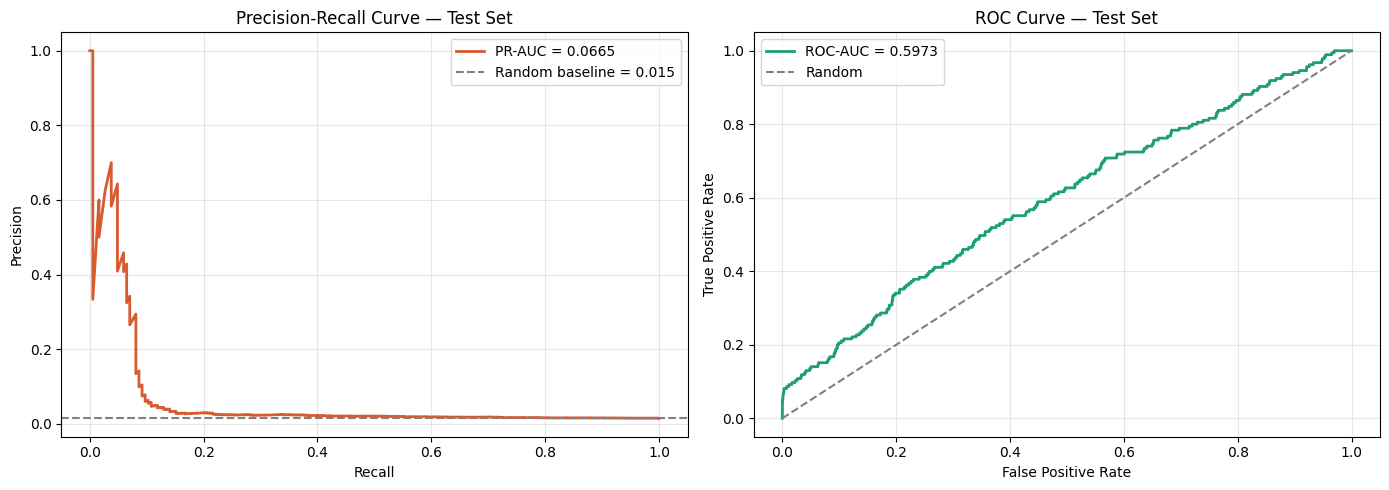

Saved: charts/churn_pr_roc_curves.png


In [19]:
from sklearn.metrics import precision_recall_curve, roc_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob_test)
fpr, tpr, _          = roc_curve(y_test, y_prob_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(recall, precision, color='#D85A30', lw=2,
         label=f'PR-AUC = {pr_test:.4f}')
ax1.axhline(y=y_test.mean(), color='gray', linestyle='--',
            label=f'Random baseline = {y_test.mean():.3f}')
ax1.set_xlabel("Recall")
ax1.set_ylabel("Precision")
ax1.set_title("Precision-Recall Curve — Test Set")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(fpr, tpr, color='#1D9E75', lw=2,
         label=f'ROC-AUC = {roc_test:.4f}')
ax2.plot([0,1],[0,1], color='gray', linestyle='--', label='Random')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve — Test Set")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../charts/churn_pr_roc_curves.png", dpi=150)
plt.show()
print("Saved: charts/churn_pr_roc_curves.png")

In [20]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = []

from sklearn.metrics import f1_score

for t in thresholds:
    y_pred_t = (y_prob_test >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

print(f"Optimal threshold: {best_threshold:.2f}")
print(f"Best F1 at optimal threshold: {best_f1:.4f}")

y_pred_optimal = (y_prob_test >= best_threshold).astype(int)
print(f"\nFinal classification report at threshold={best_threshold:.2f}:")
print(classification_report(
    y_test, y_pred_optimal,
    target_names=['One-time (churned)', 'Returned']
))

Optimal threshold: 0.89
Best F1 at optimal threshold: 0.0495

Final classification report at threshold=0.89:
                    precision    recall  f1-score   support

One-time (churned)       0.99      0.93      0.96     12549
          Returned       0.03      0.15      0.05       185

          accuracy                           0.92     12734
         macro avg       0.51      0.54      0.50     12734
      weighted avg       0.97      0.92      0.94     12734



Computing SHAP values...
SHAP values shape: (12734, 18)


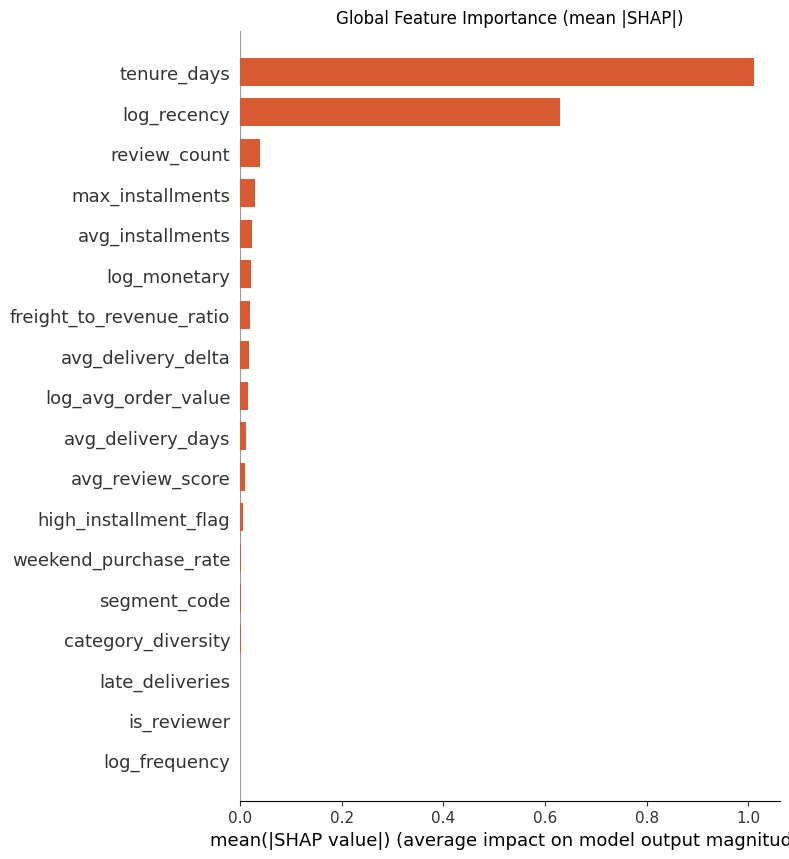

Saved: charts/shap_global_importance.png


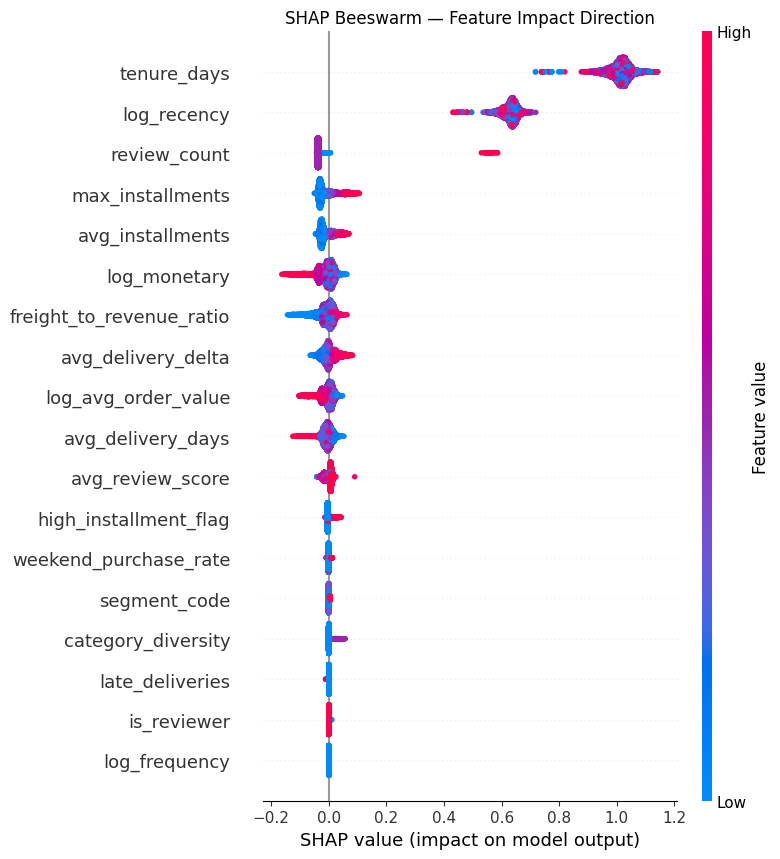

Saved: charts/shap_beeswarm.png


In [21]:
import shap

print("Computing SHAP values...")
explainer   = shap.TreeExplainer(tuned_model)
shap_values = explainer.shap_values(X_test)
print(f"SHAP values shape: {shap_values.shape}")

# Global bar chart
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=CHURN_FEATURES,
                  plot_type="bar", show=False, color='#D85A30')
plt.title("Global Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig("../charts/shap_global_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: charts/shap_global_importance.png")

# Beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=CHURN_FEATURES, show=False)
plt.title("SHAP Beeswarm — Feature Impact Direction")
plt.tight_layout()
plt.savefig("../charts/shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: charts/shap_beeswarm.png")

High-confidence returned customers in test: 185


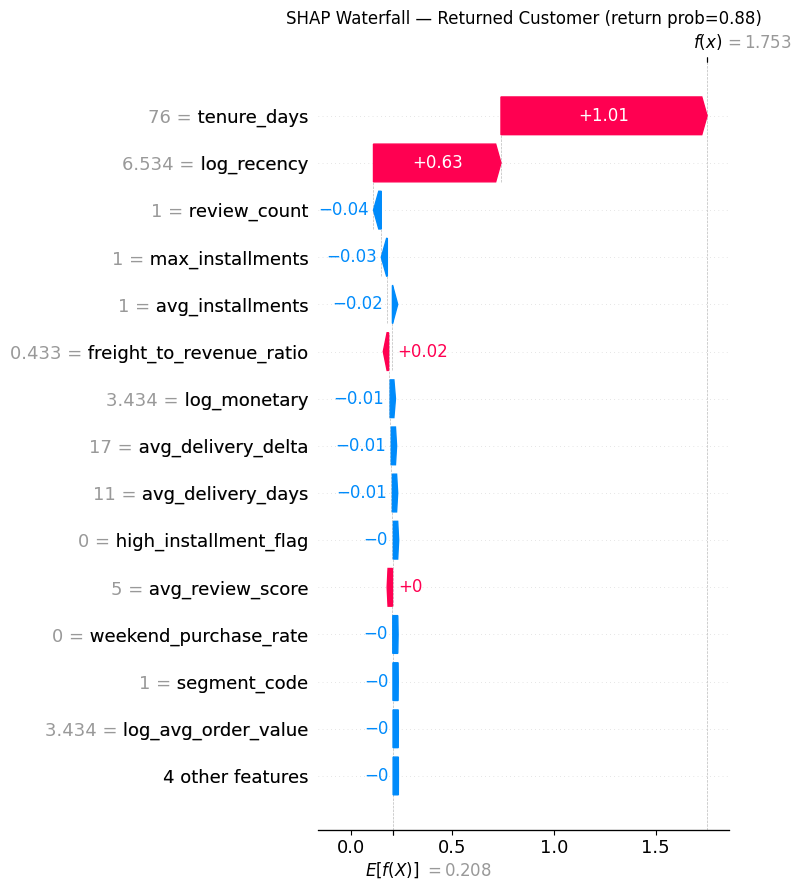

Saved: charts/shap_waterfall_returned.png

Customer feature values:
log_recency                  6.533789
log_frequency                0.693147
log_monetary                 3.433665
log_avg_order_value          3.433665
category_diversity           1.000000
avg_review_score             5.000000
review_count                 1.000000
is_reviewer                  1.000000
avg_delivery_days           11.000000
avg_delivery_delta          17.000000
late_deliveries              0.000000
avg_installments             1.000000
max_installments             1.000000
high_installment_flag        0.000000
weekend_purchase_rate        0.000000
freight_to_revenue_ratio     0.433300
tenure_days                 76.000000
segment_code                 1.000000


In [22]:
# Find a high-confidence returned customer in test set
returned_idx = np.where(
    (y_test.values == 1) & (y_prob_test > 0.6)
)[0]

print(f"High-confidence returned customers in test: {len(returned_idx)}")

if len(returned_idx) == 0:
    # Lower threshold if none found
    returned_idx = np.where(y_test.values == 1)[0]
    print("Lowered threshold — using first returned customer found")

sample_idx = returned_idx[0]

shap_explanation = shap.Explanation(
    values      = shap_values[sample_idx],
    base_values = explainer.expected_value,
    data        = X_test.iloc[sample_idx].values,
    feature_names = CHURN_FEATURES
)

plt.figure(figsize=(12, 6))
shap.waterfall_plot(shap_explanation, show=False, max_display=15)
plt.title(
    f"SHAP Waterfall — Returned Customer "
    f"(return prob={y_prob_test[sample_idx]:.2f})"
)
plt.tight_layout()
plt.savefig("../charts/shap_waterfall_returned.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: charts/shap_waterfall_returned.png")
print(f"\nCustomer feature values:")
print(X_test.iloc[sample_idx].to_string())

In [23]:
import joblib
import os

# Score entire dataset
X_all = df[CHURN_FEATURES].copy()
dall  = xgb.DMatrix(X_all, feature_names=CHURN_FEATURES)

df['return_probability'] = tuned_model.predict(dall)
df['will_return']        = (df['return_probability'] >= best_threshold).astype(int)
df['churn_risk_tier']    = pd.cut(
    1 - df['return_probability'],   # invert: low return prob = high churn risk
    bins=[0, 0.2, 0.4, 0.6, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical']
)

print("Churn risk tier distribution:")
print(df['churn_risk_tier'].value_counts().sort_index().to_string())
print(f"\nPredicted to return:    {df['will_return'].sum():,}")
print(f"Predicted to not return:{(df['will_return']==0).sum():,}")

# Save scored output
out_cols = [
    'customer_id', 'returned', 'churned',
    'return_probability', 'will_return', 'churn_risk_tier',
    'segment', 'spend_tier',
    'recency_days', 'frequency', 'monetary',
    'avg_review_score', 'tenure_days',
]
os.makedirs("../data/processed", exist_ok=True)
df[out_cols].to_csv("../data/processed/customer_churn_scores.csv", index=False)
print("Saved: ../data/processed/customer_churn_scores.csv")

# Save model artefacts
os.makedirs("../data/models", exist_ok=True)
tuned_model.save_model("../data/models/xgboost_churn.json")
joblib.dump(explainer,      "../data/models/shap_explainer.pkl")
joblib.dump(best_threshold, "../data/models/churn_threshold.pkl")
joblib.dump(CHURN_FEATURES, "../data/models/churn_features.pkl")

print("\nModels saved:")
print("  data/models/xgboost_churn.json")
print("  data/models/shap_explainer.pkl")
print("  data/models/churn_threshold.pkl")
print("  data/models/churn_features.pkl")

Churn risk tier distribution:
churn_risk_tier
Low         26134
Medium       1032
High        42690
Critical    15037

Predicted to return:    1,746
Predicted to not return:83,147
Saved: ../data/processed/customer_churn_scores.csv

Models saved:
  data/models/xgboost_churn.json
  data/models/shap_explainer.pkl
  data/models/churn_threshold.pkl
  data/models/churn_features.pkl


In [24]:
print("\n" + "="*50)
print("DAY 4 COMPLETE — CHURN MODEL SUMMARY")
print("="*50)
print(f"  Target:            Predict repeat purchase (returned=1)")
print(f"  Eligible customers:{len(df):,}")
print(f"  Return rate:       {df['returned'].mean():.1%}")
print(f"  ROC-AUC (test):    {roc_test:.4f}")
print(f"  PR-AUC  (test):    {pr_test:.4f}")
print(f"  Best F1 (test):    {best_f1:.4f}")
print(f"  Threshold:         {best_threshold:.2f}")
print(f"  Top feature:       {CHURN_FEATURES[np.argmax(np.abs(shap_values).mean(axis=0))]}")
print("="*50)


DAY 4 COMPLETE — CHURN MODEL SUMMARY
  Target:            Predict repeat purchase (returned=1)
  Eligible customers:84,893
  Return rate:       3.3%
  ROC-AUC (test):    0.5973
  PR-AUC  (test):    0.0665
  Best F1 (test):    0.0495
  Threshold:         0.89
  Top feature:       tenure_days
